<a href="https://colab.research.google.com/github/vashirij/wildfire-tinyml-self-sufficiency/blob/main/Notebooks/04_Label_Free_Pseudo_Labeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 04 Label-Free Pseudo-Labeling for Wildfire Detection

This notebook implements confidence-based pseudo-labeling with temporal consistency and multi-sensor agreement.

In [1]:
from pathlib import Path
import random
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
from google.colab import drive
drive.mount("/content/drive")

PROJECT_ROOT = Path("/content/drive/MyDrive/WildfireProject")
DATA_PATH = PROJECT_ROOT / "data" / "simulated" / "realistic" / "realistic_environment_stream.csv"
MODEL_DIR = PROJECT_ROOT / "models" / "pseudo_labeling"
METRICS_DIR = PROJECT_ROOT / "results" / "metrics"
PREDICTIONS_DIR = PROJECT_ROOT / "results" / "predictions"
RESULTS_DIR = PROJECT_ROOT / "results" / "pseudo_labeling"
FIGURES_DIR = PROJECT_ROOT / "figures" / "pseudo_labeling"
for folder in [MODEL_DIR, METRICS_DIR, PREDICTIONS_DIR, RESULTS_DIR, FIGURES_DIR]:
    folder.mkdir(parents=True, exist_ok=True)
print("Dataset exists:", DATA_PATH.exists())

Mounted at /content/drive
Dataset exists: True


In [3]:
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found: {DATA_PATH}")

df = pd.read_csv(DATA_PATH, parse_dates=["timestamp"])
FEATURE_COLUMNS = ["temperature_c", "humidity_percent", "smoke_ppm", "co_ppm", "wind_speed_kmh"]
TARGET_COLUMN = "wildfire"
required = ["timestamp", "sample_index", "fire_event_id", TARGET_COLUMN, *FEATURE_COLUMNS]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")
print("Dataset shape:", df.shape)
print(df[TARGET_COLUMN].value_counts())
display(df.head())

Dataset shape: (20000, 15)
wildfire
0    14092
1     5908
Name: count, dtype: int64


,timestamp,temperature_c,humidity_percent,smoke_ppm,co_ppm,wind_speed_kmh,solar_power_w,battery_voltage,wildfire,environment_state,fire_phase,fire_severity,fire_event_id,missing_packet,sample_index
0,2026-07-27 00:00:00,13.347181,76.569494,14.397654,0.730587,8.031726,0.0,4.14997,0,sensor_spike,none,0.0,0,False,0
1,2026-07-27 00:00:01,14.356494,64.187253,0.246029,0.580671,6.474338,0.0,4.14994,0,normal,none,0.0,0,False,1
2,2026-07-27 00:00:02,13.320607,85.195248,1.656730,0.937621,7.469129,0.0,4.14991,0,normal,none,0.0,0,False,2
3,2026-07-27 00:00:03,14.112753,68.244563,2.435927,0.366247,8.917727,0.0,4.14988,0,normal,none,0.0,0,False,3
4,2026-07-27 00:00:04,14.849696,67.837010,0.279561,1.479401,7.423717,0.0,4.14985,0,normal,none,0.0,0,False,4


In [4]:
SEED_NORMAL_SAMPLES = 475
SEED_FIRE_SAMPLES = 25
FINAL_TEST_FRACTION = 0.20
NORMAL_CONFIDENCE_THRESHOLD = 0.97
FIRE_CONFIDENCE_THRESHOLD = 0.90
TEMPORAL_WINDOW = 5
MIN_TEMPORAL_AGREEMENT = 3
MAX_PSEUDO_LABELS = 3000
FIRE_DECISION_THRESHOLD = 0.30

In [5]:
test_start = int(len(df) * (1 - FINAL_TEST_FRACTION))
development_df = df.iloc[:test_start].copy()
final_test_df = df.iloc[test_start:].copy()
normal_candidates = development_df[development_df[TARGET_COLUMN] == 0]
fire_candidates = development_df[development_df[TARGET_COLUMN] == 1]
if len(fire_candidates) < SEED_FIRE_SAMPLES:
    raise ValueError("Not enough wildfire samples for the seed set.")
seed_normal_df = normal_candidates.sample(n=SEED_NORMAL_SAMPLES, random_state=SEED)
seed_fire_df = fire_candidates.sample(n=SEED_FIRE_SAMPLES, random_state=SEED)
seed_df = pd.concat([seed_normal_df, seed_fire_df]).sample(frac=1, random_state=SEED).reset_index(drop=True)
seed_indices = set(seed_normal_df.index).union(seed_fire_df.index)
unlabeled_stream_df = development_df.drop(index=list(seed_indices)).sort_values("timestamp").reset_index(drop=True)
final_test_df = final_test_df.sort_values("timestamp").reset_index(drop=True)
X_seed = seed_df[FEATURE_COLUMNS].copy()
y_seed = seed_df[TARGET_COLUMN].astype(int).copy()
X_test = final_test_df[FEATURE_COLUMNS].copy()
y_test = final_test_df[TARGET_COLUMN].astype(int).copy()
print("Seed distribution:")
print(seed_df[TARGET_COLUMN].value_counts())

Seed distribution:
wildfire
0    475
1     25
Name: count, dtype: int64


In [6]:
def create_model(seed=SEED):
    return RandomForestClassifier(n_estimators=200, max_depth=8, min_samples_leaf=3, class_weight={0:1.0,1:5.0}, random_state=seed, n_jobs=-1)

def false_alarm_rate(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    return fp/(fp+tn) if (fp+tn)>0 else 0.0

def evaluate(name, model, X, y, labels_used):
    probs = model.predict_proba(X)[:,1]
    pred = (probs >= FIRE_DECISION_THRESHOLD).astype(int)
    return {"model":name,"accuracy":accuracy_score(y,pred),"precision":precision_score(y,pred,zero_division=0),"recall":recall_score(y,pred,zero_division=0),"f1_score":f1_score(y,pred,zero_division=0),"false_alarm_rate":false_alarm_rate(y,pred),"labels_used":int(labels_used),"predictions":pred,"probabilities":probs}

def sensor_agreement_score(row):
    score = 0
    score += int(row["temperature_c"] >= 32)
    score += int(row["humidity_percent"] <= 55)
    score += int(row["smoke_ppm"] >= 6)
    score += int(row["co_ppm"] >= 3)
    return score

def sensor_supports_label(row, label):
    score = sensor_agreement_score(row)
    return score >= 2 if label == 1 else score <= 2

In [7]:
seed_model = create_model()
seed_model.fit(X_seed, y_seed)
seed_eval = evaluate("Seed Model", seed_model, X_test, y_test, len(y_seed))
print({k:v for k,v in seed_eval.items() if k not in ["predictions","probabilities"]})

{'model': 'Seed Model', 'accuracy': 0.87525, 'precision': 0.9355140186915888, 'recall': 0.6995108315863033, 'f1_score': 0.8004798080767693, 'false_alarm_rate': np.float64(0.026858699883223043), 'labels_used': 500}


In [8]:
accepted=[]
decisions=[]
candidate_history=[]
for position, (_, row) in enumerate(unlabeled_stream_df.iterrows()):
    sample = pd.DataFrame([row[FEATURE_COLUMNS].to_dict()], columns=FEATURE_COLUMNS)
    fire_prob = float(seed_model.predict_proba(sample)[0,1])
    if fire_prob >= FIRE_CONFIDENCE_THRESHOLD:
        candidate = 1; confidence = fire_prob
    elif fire_prob <= (1 - NORMAL_CONFIDENCE_THRESHOLD):
        candidate = 0; confidence = 1-fire_prob
    else:
        candidate = None; confidence = max(fire_prob, 1-fire_prob)
    candidate_history.append(candidate)
    sensor_ok = False; temporal_ok = False; accepted_flag = False
    if candidate is not None:
        sensor_ok = sensor_supports_label(row, candidate)
        recent = [x for x in candidate_history[max(0,position-TEMPORAL_WINDOW+1):position+1] if x is not None]
        temporal_ok = len(recent) >= MIN_TEMPORAL_AGREEMENT and recent.count(candidate) >= MIN_TEMPORAL_AGREEMENT
        accepted_flag = sensor_ok and temporal_ok and len(accepted) < MAX_PSEUDO_LABELS
    decisions.append({"timestamp":row["timestamp"],"sample_index":int(row["sample_index"]),"fire_event_id":int(row["fire_event_id"]),"fire_probability":fire_prob,"candidate_label":candidate,"confidence":confidence,"sensor_agreement":sensor_ok,"temporal_consistency":temporal_ok,"accepted":accepted_flag,"true_label_for_evaluation":int(row[TARGET_COLUMN])})
    if accepted_flag:
        accepted.append({**row[FEATURE_COLUMNS].to_dict(),"pseudo_label":int(candidate),"fire_probability":fire_prob,"confidence":confidence,"timestamp":row["timestamp"],"sample_index":int(row["sample_index"]),"true_label_for_evaluation":int(row[TARGET_COLUMN])})

pseudo_labels_df = pd.DataFrame(accepted)
pseudo_decisions_df = pd.DataFrame(decisions)
print("Accepted pseudo-labels:", len(pseudo_labels_df))
display(pseudo_labels_df.head())

Accepted pseudo-labels: 3000


,temperature_c,humidity_percent,smoke_ppm,co_ppm,wind_speed_kmh,pseudo_label,fire_probability,confidence,timestamp,sample_index,true_label_for_evaluation
0,14.112753,68.244563,2.435927,0.366247,8.917727,0,0.003571,0.996429,2026-07-27 00:00:03,3,0
1,14.849696,67.837010,0.279561,1.479401,7.423717,0,0.021685,0.978315,2026-07-27 00:00:04,4,0
2,10.725031,78.636437,2.938651,1.651938,6.821565,0,0.000000,1.000000,2026-07-27 00:00:05,5,0
3,12.048272,80.067896,0.517866,1.544075,9.093123,0,0.000000,1.000000,2026-07-27 00:00:06,6,0
4,12.844830,81.123029,0.110155,1.530220,8.674094,0,0.000000,1.000000,2026-07-27 00:00:07,7,0


In [9]:
if pseudo_labels_df.empty:
    raise ValueError("No pseudo-labels accepted. Relax thresholds.")

pseudo_label_accuracy = accuracy_score(pseudo_labels_df["true_label_for_evaluation"], pseudo_labels_df["pseudo_label"])
pseudo_label_precision = precision_score(pseudo_labels_df["true_label_for_evaluation"], pseudo_labels_df["pseudo_label"], zero_division=0)
pseudo_label_recall = recall_score(pseudo_labels_df["true_label_for_evaluation"], pseudo_labels_df["pseudo_label"], zero_division=0)
print("Pseudo-label accuracy:", round(pseudo_label_accuracy,4))
print("Pseudo-label precision:", round(pseudo_label_precision,4))
print("Pseudo-label recall:", round(pseudo_label_recall,4))

Pseudo-label accuracy: 0.985
Pseudo-label precision: 1.0
Pseudo-label recall: 0.8747


In [10]:
X_pseudo = pseudo_labels_df[FEATURE_COLUMNS].copy()
y_pseudo = pseudo_labels_df["pseudo_label"].astype(int).copy()
X_combined = pd.concat([X_seed, X_pseudo], ignore_index=True)
y_combined = pd.concat([y_seed, y_pseudo], ignore_index=True)
pseudo_model = create_model(SEED+1)
pseudo_model.fit(X_combined, y_combined)
pseudo_eval = evaluate("Pseudo-Label Model", pseudo_model, X_test, y_test, len(y_combined))

X_full = pd.concat([X_seed, unlabeled_stream_df[FEATURE_COLUMNS]], ignore_index=True)
y_full = pd.concat([y_seed, unlabeled_stream_df[TARGET_COLUMN].astype(int)], ignore_index=True)
full_model = create_model(SEED+2)
full_model.fit(X_full, y_full)
full_eval = evaluate("Fully Supervised Reference", full_model, X_test, y_test, len(y_full))

def metric_row(e):
    return {k:v for k,v in e.items() if k not in ["predictions","probabilities"]}
comparison_df = pd.DataFrame([metric_row(seed_eval), metric_row(pseudo_eval), metric_row(full_eval)])
comparison_df["human_labels_used"] = [len(y_seed), len(y_seed), len(y_full)]
comparison_df["pseudo_labels_used"] = [0, len(y_pseudo), 0]
comparison_df["human_label_savings"] = 1 - comparison_df["human_labels_used"] / len(y_full)
display(comparison_df.round(4))

,model,accuracy,precision,recall,f1_score,false_alarm_rate,labels_used,human_labels_used,pseudo_labels_used,human_label_savings
0,Seed Model,0.8752,0.9355,0.6995,0.8005,0.0269,500,500,0,0.9688
1,Pseudo-Label Model,0.8702,0.9302,0.6890,0.7916,0.0288,3500,500,3000,0.9688
2,Fully Supervised Reference,0.8715,0.7589,0.9392,0.8395,0.1662,16000,16000,0,0.0000


In [11]:
joblib.dump(seed_model, MODEL_DIR / "seed_model.joblib")
joblib.dump(pseudo_model, MODEL_DIR / "pseudo_label_model.joblib")
joblib.dump(full_model, MODEL_DIR / "fully_supervised_reference.joblib")
comparison_df.to_csv(METRICS_DIR / "week4_pseudo_labeling_comparison.csv", index=False)
pseudo_labels_df.to_csv(RESULTS_DIR / "week4_accepted_pseudo_labels.csv", index=False)
pseudo_decisions_df.to_csv(RESULTS_DIR / "week4_pseudo_label_decisions.csv", index=False)

predictions_df = final_test_df[["timestamp","sample_index","fire_event_id",TARGET_COLUMN]].copy()
predictions_df["seed_prediction"] = seed_eval["predictions"]
predictions_df["pseudo_prediction"] = pseudo_eval["predictions"]
predictions_df["fully_supervised_prediction"] = full_eval["predictions"]
predictions_df.to_csv(PREDICTIONS_DIR / "week4_pseudo_label_test_predictions.csv", index=False)
print("Outputs saved successfully.")

Outputs saved successfully.


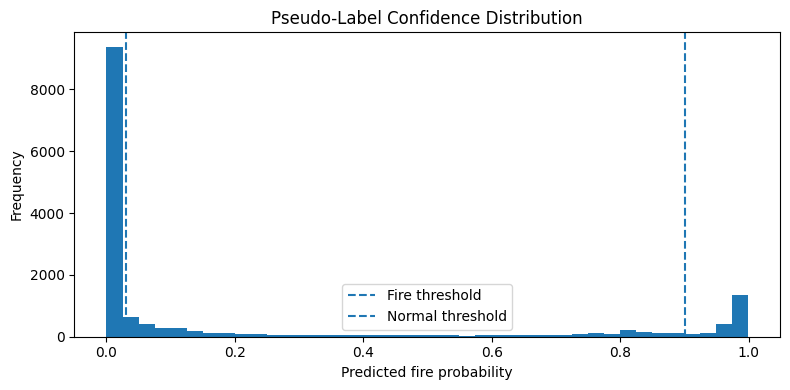

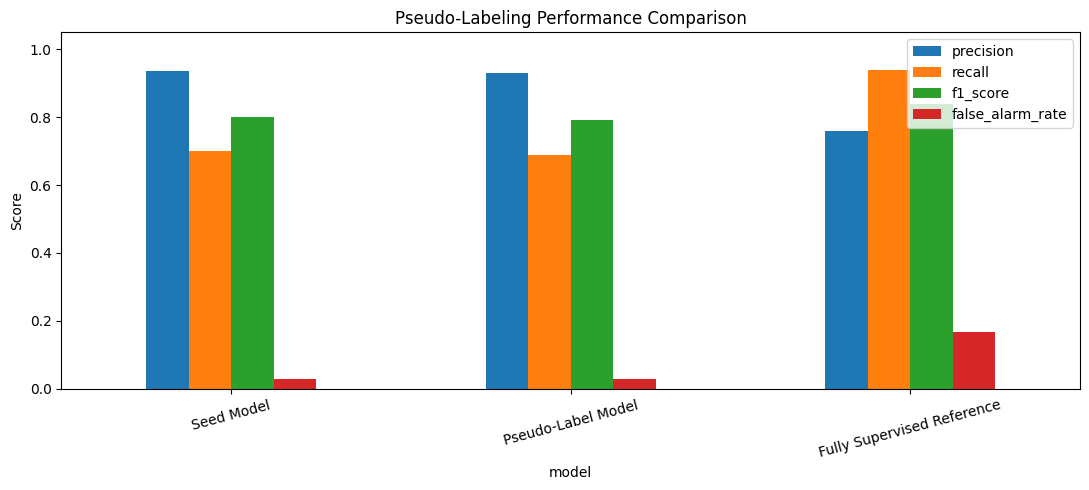

In [12]:
plt.figure(figsize=(8,4))
plt.hist(pseudo_decisions_df["fire_probability"], bins=40)
plt.axvline(FIRE_CONFIDENCE_THRESHOLD, linestyle="--", label="Fire threshold")
plt.axvline(1-NORMAL_CONFIDENCE_THRESHOLD, linestyle="--", label="Normal threshold")
plt.xlabel("Predicted fire probability")
plt.ylabel("Frequency")
plt.title("Pseudo-Label Confidence Distribution")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "pseudo_label_confidence_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

ax = comparison_df.set_index("model")[["precision","recall","f1_score","false_alarm_rate"]].plot(kind="bar", figsize=(11,5))
ax.set_ylabel("Score")
ax.set_ylim(0,1.05)
ax.set_title("Pseudo-Labeling Performance Comparison")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "pseudo_labeling_performance.png", dpi=300, bbox_inches="tight")
plt.show()

In [13]:
pseudo_row = comparison_df[comparison_df["model"] == "Pseudo-Label Model"].iloc[0]
summary_df = pd.DataFrame([{
    "seed_human_labels":len(y_seed),
    "accepted_pseudo_labels":len(y_pseudo),
    "pseudo_label_accuracy":pseudo_label_accuracy,
    "pseudo_label_precision":pseudo_label_precision,
    "pseudo_label_recall":pseudo_label_recall,
    "test_accuracy":pseudo_row["accuracy"],
    "test_precision":pseudo_row["precision"],
    "test_recall":pseudo_row["recall"],
    "test_f1_score":pseudo_row["f1_score"],
    "false_alarm_rate":pseudo_row["false_alarm_rate"],
    "human_label_savings":pseudo_row["human_label_savings"]
}])
summary_df.to_csv(RESULTS_DIR / "week4_pseudo_labeling_summary.csv", index=False)
display(summary_df.round(4))
print("="*70)
print("LABEL-FREE PSEUDO-LABELING COMPLETED SUCCESSFULLY")
print("="*70)
print("Human seed labels:", len(y_seed))
print("Accepted pseudo-labels:", len(y_pseudo))
print("Pseudo-label accuracy:", round(pseudo_label_accuracy,4))
print("Test recall:", round(pseudo_row["recall"],4))
print("Test F1-score:", round(pseudo_row["f1_score"],4))

,seed_human_labels,accepted_pseudo_labels,pseudo_label_accuracy,pseudo_label_precision,pseudo_label_recall,test_accuracy,test_precision,test_recall,test_f1_score,false_alarm_rate,human_label_savings
0,500,3000,0.985,1.0,0.8747,0.8702,0.9302,0.689,0.7916,0.0288,0.9688


LABEL-FREE PSEUDO-LABELING COMPLETED SUCCESSFULLY
Human seed labels: 500
Accepted pseudo-labels: 3000
Pseudo-label accuracy: 0.985
Test recall: 0.689
Test F1-score: 0.7916
